## Задача 1

Реализовать класс для работы с линейной регрессией

In [478]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.preprocessing import StandardScaler

In [479]:
class MyLinearRegression:
    """
    Parameters
    ----------
    regularization : {None, 'l1', 'l2', 'l1l2'}, default=None
        Какую регуляризацию добавить к модели. Если значение `None`, то без регуляризации.

    weight_calc : {'matrix', 'gd', 'sgd'}, default='matrix'
        Каким образом вычислять вектор весов: матрично ('matrix'), градиентным спуском ('gd') или стохастическим градиентным спуском ('sgd'). При этом, при 'l1' или 'l1l2' нельзя использовать параметр 'matrix'.

    Attributes
    ----------
    coefs_ : Вектор коэффициентов размера (p, 1), где p — количество признаков.
    intercept_ : Значение коэффициента, отвечающего за смещение
    """

    def __init__(self, regularization = None, weight_calc = 'matrix', lambda_1 = None, lambda_2 = None, batch_size = 20,
                 random_state = 42, alpha = 0.001, max_iter = 5000, early_stopping = 0.0001):
        if regularization not in [None, 'l1', 'l2', 'l1l2']:
            raise TypeError(f"Параметр regularization не может принимать значение '{regularization}'")
        if weight_calc not in ['matrix', 'gd', 'sgd']:
            raise TypeError(f"Параметр weight_calc не может принимать значение '{weight_calc}'")
        if regularization in ['l1', 'l1l2'] and lambda_1 is None:
            raise TypeError(f"Значение коэффициента регулризации l1 не задано")
        if regularization in ['l2', 'l1l2'] and lambda_2 is None:
            raise TypeError(f"Значение коэффициента регулризации l2 не задано")

        self.regularization = regularization
        self.weight_calc = weight_calc
        self.coefs_ = None
        self.intercept_ = None
        self.lambda_1 = lambda_1
        self.lambda_2 = lambda_2
        self.batch_size = batch_size
        self.random_state = random_state
        self.alpha = alpha
        self.max_iter = max_iter
        self.early_stopping = early_stopping
    
    def _initialization(self, X):

        np.random.seed(self.random_state)
        X_new = np.hstack((np.ones((X.shape[0], 1)), X))
        W = np.random.uniform(size = (X_new.shape[1], 1))
        return X_new, W

    def _get_gradient(self, X, Y, W):
      
        grad = 2 / X.shape[0] * X.T @ (X @ W - Y)
    
        if self.regularization == 'l1':
            grad[1:] += (self.lambda_1 / X.shape[0]) * np.sign(W[1:])
        elif self.regularization == 'l2':
            grad[1:] += 2 * (self.lambda_2 / X.shape[0]) * W[1:]
        elif self.regularization == 'l1l2':
            grad[1:] += (self.lambda_1 / X.shape[0]) * np.sign(W[1:]) + 2 * (self.lambda_2 / X.shape[0]) * W[1:]
        
        return grad
    
    def GD_regression(self, X, Y):
        '''
        Gradient descent
        '''
        X_new, W = self._initialization(X)
        for _ in range(self.max_iter):

            grad = self._get_gradient(X_new, Y, W)
            W_new = W - self.alpha * grad

            if np.linalg.norm(W_new - W) < self.early_stopping:
                return W[0], W[1:]
            
            W = W_new

        return W[0], W[1:]
    
    def SGD_regression(self, X, Y):
        '''
        Stochastic gradient descent
        '''
        X_new, W = self._initialization(X)
        n_samples = X.shape[0]

        for _ in range(self.max_iter):
            indices = np.random.permutation(n_samples)

            X_shuffled = X_new[indices]
            y_shuffled = Y[indices]

            for j in range(0, n_samples, self.batch_size):
                X_batch = X_shuffled[j:j + self.batch_size]
                y_batch = y_shuffled[j:j + self.batch_size]

                grad = self._get_gradient(X_batch, y_batch, W)

                W_new = W - self.alpha * grad

                if np.linalg.norm(W_new - W) < self.early_stopping:
                    return W[0], W[1:]
                
                W = W_new

        return W[0], W[1:]

    def fit(self, X: np.array, y: np.array):
        '''
        Fit linear model.
        '''
        X_np = X
        y_np = y if len(y.shape) == 2 else y.reshape(-1, 1)

        if self.weight_calc == 'matrix':

            if self.regularization in ['l1', 'l1l2']:
                raise ValueError("L1 и L1L2 регуляризация не поддерживаются для матричного решения")

            X_new = np.hstack((np.ones((X_np.shape[0], 1)), X_np))

            if self.regularization == 'l2':
                theta_full = np.linalg.inv(X_new.T @ X_new + self.lambda_2 * np.eye(X_new.shape[1], X_new.shape[1])) @ X_new.T @ y_np
            else:
                theta_full = np.linalg.inv(X_new.T @ X_new) @ X_new.T @ y_np
            
            self.intercept_ = theta_full[0][0]
            self.coefs_ = theta_full[1:]

        elif self.weight_calc == 'gd':
            theta_full = self.GD_regression(X_np, y_np)
            self.intercept_ = theta_full[0][0]
            self.coefs_ = theta_full[1]
        
        else:
            theta_full = self.SGD_regression(X_np, y_np)
            self.intercept_ = theta_full[0][0]
            self.coefs_ = theta_full[1]
        
        return self

    def predict(self, X: np.array):
        '''
        Predict using the linear model.
        '''
        X_with_intercept = np.hstack((np.ones((X.shape[0], 1)), X))
        theta_full = np.vstack((self.intercept_, self.coefs_))

        return X_with_intercept @ theta_full

    def score(self, X: np.array, y: np.array) -> float:
        '''
        Return coefficient of determination on test data.
        '''
        y = y.reshape(-1, 1) if len(y.shape) == 1 else y
        y_pred = self.predict(X)
        u = np.sum((y - y_pred) ** 2)
        v = np.sum((y - np.mean(y)) ** 2)
        
        return 1 - (u / v)

Проверим реализованный класс на корректность, сравнив с библиотечным классом.

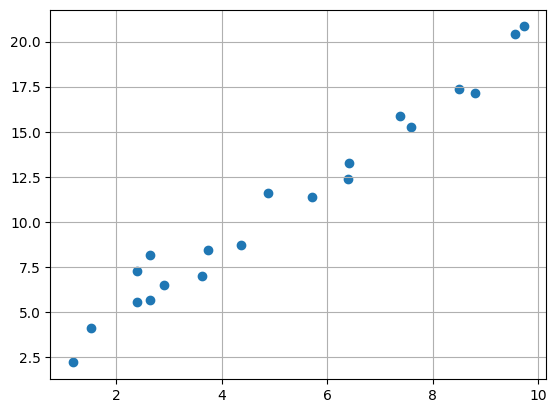

In [480]:
n_samples = 20
np.random.seed(42)

X = np.random.uniform(1, 10, (n_samples, 1))
y = (2 * X + 1 + np.random.normal(0, 1, (n_samples, 1)))

plt.grid(True)
plt.scatter(X, y)

**Матричное** решение

In [481]:
linreg = MyLinearRegression()
linreg.fit(X, y)
theta_0 = linreg.intercept_
theta = linreg.coefs_
linreg.intercept_, linreg.coefs_

(np.float64(1.0209977511594355), array([[1.94260725]]))

In [482]:
linreg_ = LinearRegression().fit(X, y)
linreg_.intercept_, linreg_.coef_

(array([1.02099775]), array([[1.94260725]]))

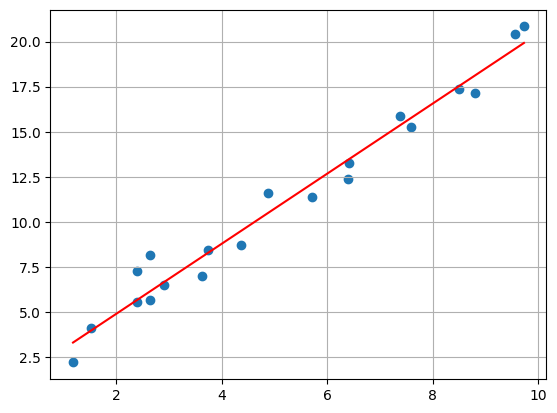

In [483]:
plt.scatter(X, y)
x = np.linspace(np.min(X), np.max(X), 100)
y2 = x * theta[0] + theta_0
plt.grid(True)
plt.plot(x, y2, color = 'red')
plt.show()

In [484]:
X_new = np.random.uniform(-10, 0, (100, 1))
y_new = (2 * X_new + 1 + np.random.normal(0, 1, (100, 1))).reshape(-1)
print(f'My Linear Regression score: {linreg.score(X_new, y_new):.8f}')
y_pred = linreg_.predict(X_new)
print(f'Sklearn Regresion score: {r2_score(y_new, y_pred):.8f}')

My Linear Regression score: 0.97043909
Sklearn Regresion score: 0.97043909


Решение **градиентным спуском**

In [485]:
linreg = MyLinearRegression(weight_calc = 'gd')
linreg.fit(X, y)
theta_0 = linreg.intercept_
theta = linreg.coefs_
linreg.intercept_, linreg.coefs_

(np.float64(0.7884781072302046), array([[1.97837489]]))

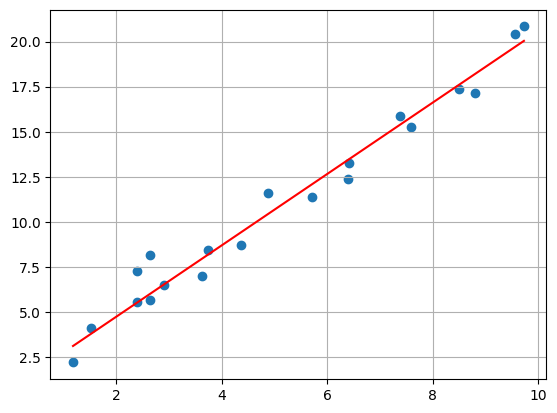

In [486]:
plt.scatter(X, y)
x = np.linspace(np.min(X), np.max(X), 100)
y2 = x * theta[0] + theta_0
plt.grid(True)
plt.plot(x, y2, color = 'red')
plt.show()

In [487]:
X_new = np.random.uniform(-10, 0, (100, 1))
y_new = (2 * X_new + 1 + np.random.normal(0, 1, (100, 1))).reshape(-1)
print(f'My Linear Regression score: {linreg.score(X_new, y_new):.8f}')
y_pred = linreg_.predict(X_new)
print(f'Sklearn Regresion score: {r2_score(y_new, y_pred):.8f}')

My Linear Regression score: 0.97537191
Sklearn Regresion score: 0.97291389


Решение **стохастическим градиентным спуском**

In [488]:
linreg = MyLinearRegression(weight_calc = 'sgd')
linreg.fit(X, y)
theta_0 = linreg.intercept_
theta = linreg.coefs_
linreg.intercept_, linreg.coefs_

(np.float64(0.7884781072302045), array([[1.97837489]]))

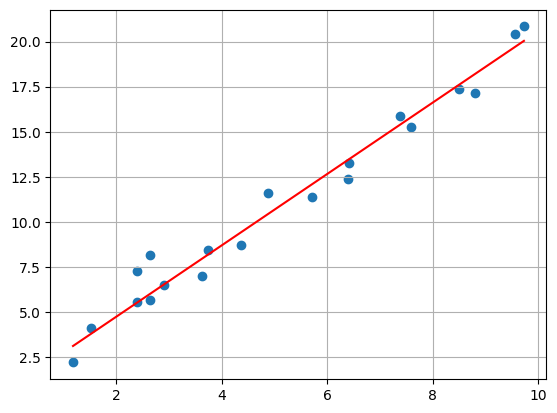

In [489]:
plt.scatter(X, y)
x = np.linspace(np.min(X), np.max(X), 100)
y3 = x * theta[0] + theta_0
plt.grid(True)
plt.plot(x, y3, color = 'red')
plt.show()

In [490]:
X_new = np.random.uniform(-10, 0, (100, 1))
y_new = (2 * X_new + 1 + np.random.normal(0, 1, (100, 1))).reshape(-1)
print(f'My Linear Regression score: {linreg.score(X_new, y_new):.8f}')
y_pred = linreg_.predict(X_new)
print(f'Sklearn Regresion score: {r2_score(y_new, y_pred):.8f}')

My Linear Regression score: 0.97666284
Sklearn Regresion score: 0.97000852


Используя датасет про автомобили (целевой признак — price), сравнить (качество, скорость обучения и предсказания, важность признаков) модели `MyLinearRegression` с различными гиперпараметрами, сделать выводы. На этом же датасете сравнить модель `MyLinearRegression` с библиотечной реализацией из `sklearn`, составить таблицу(ы) (графики) результатов сравнения (качество, скорость обучения и предсказания, важность признаков).

In [491]:
df = pd.read_csv('./data/data.csv')
df.head()

,model,engine_power,transmission,age_in_days,km,previous_owners,lat,lon,price
0,pop,69,manual,4474,56779,2,45.071079,7.46403,4490
1,lounge,69,manual,2708,160000,1,45.069679,7.70492,4500
2,lounge,69,automatic,3470,170000,2,45.514599,9.28434,4500
3,sport,69,manual,3288,132000,2,41.903221,12.49565,4700
4,sport,69,manual,3712,124490,2,45.532661,9.03892,4790


In [492]:
df.dtypes

model               object
engine_power         int64
transmission        object
age_in_days          int64
km                   int64
previous_owners      int64
lat                float64
lon                float64
price                int64
dtype: object

Избавимся от категориальных данных

In [493]:
# X = df.drop(columns = ['model', 'transmission', 'previous_owners', 'price']).to_numpy()
# y = df['price'].to_numpy()
# X = (X - X.mean(axis = 0)) / X.std(axis = 0)
# y.mean()

In [494]:
numeric_params = ['engine_power', 'age_in_days', 'km', 'lat', 'lon', 'previous_owners']
categorical_params = ['model', 'transmission']

numeric_data = df[numeric_params]
categorical_data = df[categorical_params]

scaler = StandardScaler()
numeric_scaled = scaler.fit_transform(numeric_data)

categorical_encoded = pd.get_dummies(categorical_data, drop_first = True)

X = np.hstack([numeric_scaled, categorical_encoded.to_numpy()])
y = df['price'].to_numpy()

Разделим данные на тренировочные и тестовые

In [495]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [496]:
# Без регуляризации
weight_calcs = ['matrix', 'gd', 'sgd']

data = []
for weight_calc in weight_calcs:

    linreg = MyLinearRegression(weight_calc = weight_calc)
    start_train = time.time_ns()
    linreg.fit(X_train, y_train)
    end_train = time.time_ns() - start_train
    
    print(f'Weight_calc: {weight_calc}')
    start_predict = time.time_ns()
    score = linreg.score(X_test, y_test)
    end_predict = time.time_ns() - start_predict
    coefs = list(map(int, [linreg.intercept_, *linreg.coefs_.reshape(-1)]))
    print(f'My Linear Regression score: {score:.8f}, coefs: {coefs}')

    data.append([weight_calc, '', 0, 0, score, coefs, end_train, end_predict])

Weight_calc: matrix
My Linear Regression score: 0.89453371, coefs: [5838, 39, -1583, -562, 186, 243, 49, 105, 145, 623, -12]
Weight_calc: gd
My Linear Regression score: 0.77578346, coefs: [3710, 0, -1630, -536, 167, 247, 15, 283, 342, 41, 2103]
Weight_calc: sgd
My Linear Regression score: 0.89378966, coefs: [5822, 41, -1596, -562, 188, 242, 47, 110, 143, 257, 6]


In [497]:
# Обычная линейная регрессия
linreg_ = LinearRegression()

start_train = time.time_ns()
linreg_.fit(X_train, y_train)
end_train = time.time_ns() - start_train

start_predict = time.time_ns()
y_pred = linreg_.predict(X_test)
end_predict = time.time_ns() - start_predict
score = r2_score(y_test, y_pred)
coefs = list(map(round, [linreg_.intercept_, *linreg_.coef_]))
print(f'Sklearn Regresion: {score:.8f}, coefs: {score}')

data.append(['sklearn_regresion', '', 0, 0, score, coefs, end_train, end_predict])

Sklearn Regresion: 0.89453371, coefs: 0.8945337093911585


In [498]:
alphas = {
    'l1': np.logspace(-4, 0, 5),          
    'l2': np.logspace(-3, 2, 6),          
    'l1l2': np.concatenate([np.logspace(-1, 0, 5, base = 10), np.logspace(-3, 1, 5)])
}

In [499]:
# L1 (LASSO)

for alpha in alphas['l1']:
    lasso_ = Lasso(alpha = alpha, max_iter = 5000, random_state = 42)
    start_train = time.time_ns()
    lasso_.fit(X_train, y_train)
    end_train = time.time_ns() - start_train
    
    start_predict = time.time_ns()
    score = lasso_.score(X_test, y_test)
    end_predict = time.time_ns() - start_predict
    
    coefs = list(map(round, [lasso_.intercept_, *lasso_.coef_]))
    print(f'Sklearn LASSO: {score:.8f}, alpha: {alpha}, coefs: {coefs}')
    data.append(['lasso', 'l1', alpha, 0, score, coefs, end_train, end_predict])

Sklearn LASSO: 0.89453366, alpha: 0.0001, coefs: [5839, 39, -1583, -562, 187, 243, 50, 106, 145, 623, -13]
Sklearn LASSO: 0.89453322, alpha: 0.001, coefs: [5839, 39, -1583, -562, 187, 243, 50, 106, 145, 623, -13]
Sklearn LASSO: 0.89452877, alpha: 0.01, coefs: [5839, 39, -1583, -562, 187, 243, 50, 106, 145, 620, -13]
Sklearn LASSO: 0.89448418, alpha: 0.1, coefs: [5837, 39, -1583, -562, 187, 243, 49, 105, 144, 592, -11]
Sklearn LASSO: 0.89417285, alpha: 1.0, coefs: [5832, 38, -1584, -562, 184, 240, 47, 96, 134, 313, 0]


In [500]:
# L2 (Ridge)

for alpha in alphas['l2']:
    ridge_ = Ridge(alpha = alpha, max_iter = 5000, random_state = 42)
    start_train = time.time_ns()
    ridge_.fit(X_train, y_train)
    end_train = time.time_ns() - start_train

    start_predict = time.time_ns()
    score = ridge_.score(X_test, y_test)
    end_predict = time.time_ns() - start_predict

    coefs = list(map(round, [ridge_.intercept_, *ridge_.coef_]))
    print(f'Sklearn Ridge: {score:.8f}, alpha: {alpha}, coefs: {coefs}')
    data.append(['ridge', 'l2', 0, alpha, score, coefs, end_train, end_predict])

Sklearn Ridge: 0.89453352, alpha: 0.001, coefs: [5839, 39, -1583, -562, 187, 243, 50, 106, 145, 623, -13]
Sklearn Ridge: 0.89453185, alpha: 0.01, coefs: [5839, 39, -1583, -562, 187, 243, 50, 106, 145, 617, -13]
Sklearn Ridge: 0.89451536, alpha: 0.1, coefs: [5839, 39, -1583, -563, 187, 243, 50, 105, 144, 566, -13]
Sklearn Ridge: 0.89435935, alpha: 1.0, coefs: [5842, 38, -1575, -568, 186, 242, 49, 100, 137, 313, -12]
Sklearn Ridge: 0.89240502, alpha: 10.0, coefs: [5859, 30, -1499, -599, 166, 220, 48, 63, 89, 65, -13]
Sklearn Ridge: 0.85414531, alpha: 100.0, coefs: [5881, -30, -1096, -658, 68, 106, 38, -18, -11, 14, -11]


In [501]:
# ElasticNet
for i in range(len(alphas['l1l2']) // 2):
    lambda_1 = alphas['l1l2'][i]
    lambda_2 = alphas['l1l2'][i + 5]
    elasticNet_ = ElasticNet(alpha = lambda_1 + lambda_2,
                               l1_ratio = lambda_1 / (lambda_1 + lambda_2 + 1e-8),
                               max_iter = 5000, random_state = 42)
    
    start_train = time.time_ns()
    elasticNet_.fit(X_train, y_train)
    end_train = time.time_ns() - start_train

    start_predict = time.time_ns()
    score = elasticNet_.score(X_test, y_test)
    end_predict = time.time_ns() - start_predict

    coefs = list(map(round, [elasticNet_.intercept_, *elasticNet_.coef_]))
    print(f'Sklearn ElasticNet: {score:.8f}, alpha: {lambda_1 + lambda_2}, l1_ratio = {lambda_1 / (lambda_1 + lambda_2 + 1e-8)}, coefs: {coefs}')
    data.append(['elasticnet', 'l1l2', lambda_1 / (lambda_1 + lambda_2 + 1e-8), lambda_1 + lambda_2, score, coefs, end_train, end_predict])

Sklearn ElasticNet: 0.89443045, alpha: 0.101, l1_ratio = 0.9900989118713949, coefs: [5838, 39, -1581, -564, 187, 243, 49, 103, 141, 454, -10]
Sklearn ElasticNet: 0.89391393, alpha: 0.1878279410038923, l1_ratio = 0.9467597343922856, coefs: [5845, 37, -1557, -576, 181, 236, 48, 88, 122, 146, -9]
Sklearn ElasticNet: 0.88571099, alpha: 0.416227766016838, l1_ratio = 0.7597469083948049, coefs: [5875, 12, -1365, -638, 128, 178, 46, 19, 35, 26, -11]
Sklearn ElasticNet: 0.74284852, alpha: 1.562341325190349, l1_ratio = 0.35993499789329697, coefs: [5864, -71, -749, -549, 23, 41, 22, -24, -25, 7, -6]
Sklearn ElasticNet: 0.20821066, alpha: 11.0, l1_ratio = 0.09090909082644627, coefs: [5814, -34, -160, -137, 2, 1, 2, -6, -9, 1, -1]


In [502]:
# С регуляризацией
weight_calcs = ['gd', 'sgd']

for weight_calc in weight_calcs:
    for item in alphas.items():
        for i in range(len(item[1]) if item[0] != 'l1l2' else len(item[1]) // 2):
            lambda_1, lambda_2 = 0, 0
            if item[0] == 'l1':
                lambda_1 = item[1][i]
                linreg = MyLinearRegression(weight_calc = weight_calc, regularization = item[0], lambda_1 = lambda_1)

            elif item[0] == 'l2':
                lambda_2 = item[1][i]
                linreg = MyLinearRegression(weight_calc = weight_calc, regularization = item[0], lambda_2 = lambda_2)

            else:
                lambda_1 = item[1][i]
                lambda_2 = item[1][i + 5]
                linreg = MyLinearRegression(weight_calc = weight_calc, regularization = item[0], 
                                            lambda_1 = item[1][i], lambda_2 = item[1][i + 5])
            
            start_train = time.time_ns()
            linreg.fit(X_train, y_train)
            end_train = time.time_ns() - start_train

            start_predict = time.time_ns()
            score = linreg.score(X_test, y_test)
            end_predict = time.time_ns() - start_predict

            coefs = list(map(round, [linreg.intercept_, *linreg.coefs_.reshape(-1)]))
            data.append([weight_calc, item[0], lambda_1, lambda_2, score, coefs, end_train, end_predict])

for alpha in alphas['l2']:
    linreg = MyLinearRegression(regularization = 'l2', lambda_2 = alpha)
    start_train = time.time_ns()
    linreg.fit(X_train, y_train)
    end_train = time.time_ns() - start_train

    start_predict = time.time_ns()
    score = linreg.score(X_test, y_test)
    end_predict = time.time_ns() - start_predict

    coefs = list(map(round, [linreg.intercept_, *linreg.coefs_.reshape(-1)]))
    data.append(['matrix', 'l2', 0, alpha, score, coefs, end_train, end_predict])


df_res = pd.DataFrame(data, columns = ['weight_calc', 'reg', 'lambda_1', 'lambda_2', 'score', 'coefs','train_time', 'predict_time'])
df_res.head()

,weight_calc,reg,lambda_1,lambda_2,score,coefs,train_time,predict_time
0,matrix,,0.0000,0.0,0.894534,"[5838, 39, -1583, -562, 186, 243, 49, 105, 145...",1003000,0
1,gd,,0.0000,0.0,0.775783,"[3710, 0, -1630, -536, 167, 247, 15, 283, 342,...",78656900,0
2,sgd,,0.0000,0.0,0.893790,"[5822, 41, -1596, -562, 188, 242, 47, 110, 143...",1153079700,0
3,sklearn_regresion,,0.0000,0.0,0.894534,"[5839, 39, -1583, -562, 187, 243, 50, 106, 145...",1000800,998800
4,lasso,l1,0.0001,0.0,0.894534,"[5839, 39, -1583, -562, 187, 243, 50, 106, 145...",1998700,998400


In [503]:
# Без регуляризации
df_res[df_res['reg'] == ''].sort_values(by = 'score', ascending = False)

,weight_calc,reg,lambda_1,lambda_2,score,coefs,train_time,predict_time
0,matrix,,0.0,0.0,0.894534,"[5838, 39, -1583, -562, 186, 243, 49, 105, 145...",1003000,0
3,sklearn_regresion,,0.0,0.0,0.894534,"[5839, 39, -1583, -562, 187, 243, 50, 106, 145...",1000800,998800
2,sgd,,0.0,0.0,0.893790,"[5822, 41, -1596, -562, 188, 242, 47, 110, 143...",1153079700,0
1,gd,,0.0,0.0,0.775783,"[3710, 0, -1630, -536, 167, 247, 15, 283, 342,...",78656900,0


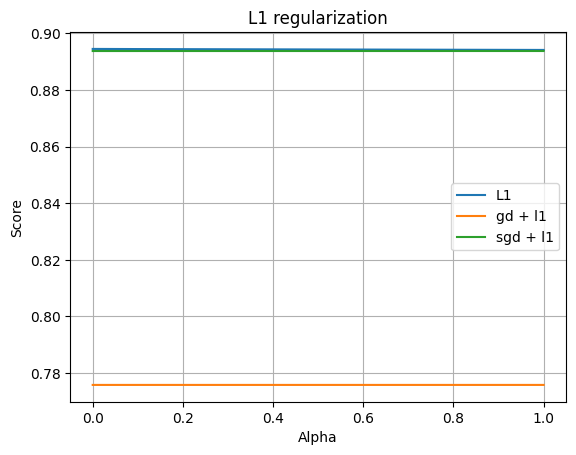

In [504]:
# Регулярицация L1 + l1(gd, sgd)
df_tmp = df_res[(df_res['reg'] == 'l1')]
y_lasso = df_tmp[df_tmp['weight_calc'] == 'lasso']['score']
y_gd = df_tmp[df_tmp['weight_calc'] == 'gd']['score']
y_sgd = df_tmp[df_tmp['weight_calc'] == 'sgd']['score']

plt.plot(alphas['l1'], y_lasso, label = "L1")
plt.plot(alphas['l1'], y_gd, label = "gd + l1")
plt.plot(alphas['l1'], y_sgd, label = "sgd + l1")
plt.xlabel('Alpha')
plt.ylabel('Score')
plt.title('L1 regularization')
plt.grid(True)
plt.legend()
plt.show()

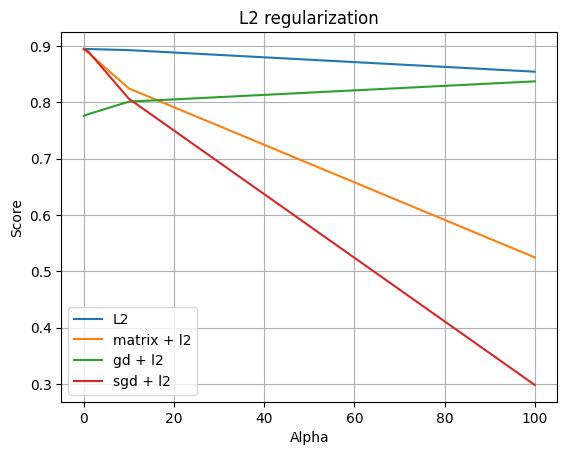

In [505]:
# Регулярицация L2 + l2(matrix, gd, sgd)
df_tmp = df_res[(df_res['reg'] == 'l2')]
y_ridge = df_tmp[df_tmp['weight_calc'] == 'ridge']['score']
y_matrix = df_tmp[df_tmp['weight_calc'] == 'matrix']['score']
y_gd = df_tmp[df_tmp['weight_calc'] == 'gd']['score']
y_sgd = df_tmp[df_tmp['weight_calc'] == 'sgd']['score']

plt.plot(alphas['l2'], y_ridge, label = "L2")
plt.plot(alphas['l2'], y_matrix, label = "matrix + l2")
plt.plot(alphas['l2'], y_gd, label = "gd + l2")
plt.plot(alphas['l2'], y_sgd, label = "sgd + l2")
plt.xlabel('Alpha')
plt.ylabel('Score')
plt.title('L2 regularization')
plt.grid(True)
plt.legend()
plt.show()

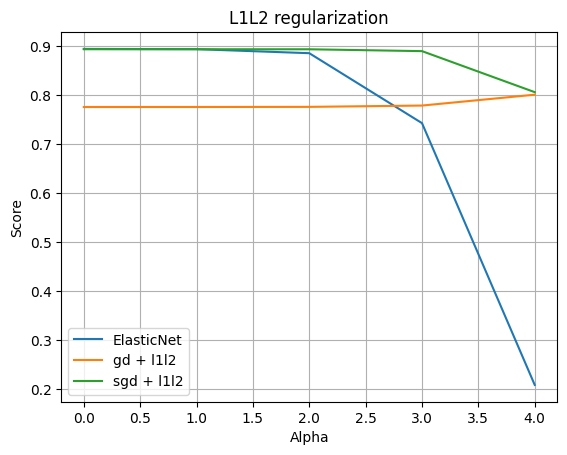

,weight_calc,reg,lambda_1,lambda_2,score,coefs,train_time,predict_time
15,elasticnet,l1l2,0.990099,0.101000,0.894430,"[5838, 39, -1581, -564, 187, 243, 49, 103, 141...",2640400,994000
16,elasticnet,l1l2,0.946760,0.187828,0.893914,"[5845, 37, -1557, -576, 181, 236, 48, 88, 122,...",2008800,991600
17,elasticnet,l1l2,0.759747,0.416228,0.885711,"[5875, 12, -1365, -638, 128, 178, 46, 19, 35, ...",2001600,1001100
18,elasticnet,l1l2,0.359935,1.562341,0.742849,"[5864, -71, -749, -549, 23, 41, 22, -24, -25, ...",996100,993500
19,elasticnet,l1l2,0.090909,11.000000,0.208211,"[5814, -34, -160, -137, 2, 1, 2, -6, -9, 1, -1]",1000900,998600
31,gd,l1l2,0.100000,0.001000,0.775787,"[3711, 0, -1630, -536, 167, 247, 16, 284, 343,...",110661800,0
32,gd,l1l2,0.177828,0.010000,0.775814,"[3711, 0, -1630, -536, 167, 247, 16, 284, 343,...",106124200,0
33,gd,l1l2,0.316228,0.100000,0.776087,"[3714, 0, -1629, -537, 167, 247, 16, 283, 342,...",106854600,0
34,gd,l1l2,0.562341,1.000000,0.778762,"[3742, 0, -1621, -540, 165, 245, 16, 280, 337,...",106728300,0
35,gd,l1l2,1.000000,10.000000,0.800968,"[4003, -3, -1544, -569, 148, 223, 20, 251, 291...",106123500,0


In [506]:
# Регулярицация ElasticNet + l2(matrix, gd, sgd)
df_tmp = df_res[(df_res['reg'] == 'l1l2')]
y_elastic = df_tmp[df_tmp['weight_calc'] == 'elasticnet']['score']
y_gd = df_tmp[df_tmp['weight_calc'] == 'gd']['score']
y_sgd = df_tmp[df_tmp['weight_calc'] == 'sgd']['score']

x = np.linspace(0, 4, 5)
plt.plot(x, y_elastic, label = "ElasticNet")
plt.plot(x, y_gd, label = "gd + l1l2")
plt.plot(x, y_sgd, label = "sgd + l1l2")
plt.xlabel('Alpha')
plt.ylabel('Score')
plt.title('L1L2 regularization')
plt.grid(True)
plt.legend()
plt.show()
df_tmp

**Выводы**

In [507]:
# Модели с лучшим score
df_best = df_res[df_res['score'] == df_res['score'].max()]
df_best

,weight_calc,reg,lambda_1,lambda_2,score,coefs,train_time,predict_time
0,matrix,,0.0,0.0,0.894534,"[5838, 39, -1583, -562, 186, 243, 49, 105, 145...",1003000,0


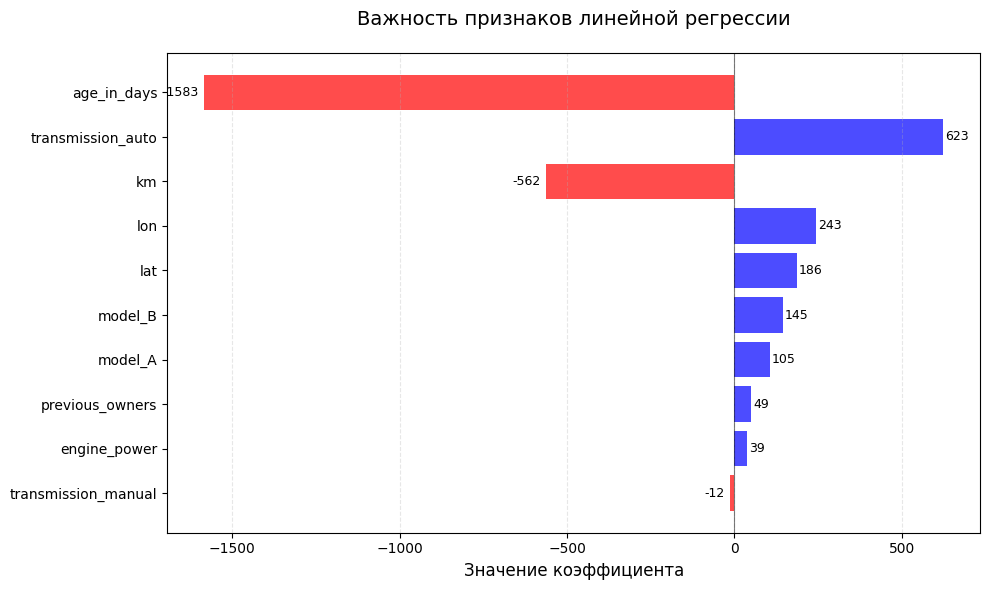

In [508]:
coefs = df_best['coefs'][0][1:]
params = ['engine_power', 'age_in_days', 'km', 'lat', 'lon', 
          'previous_owners', 'model_A', 'model_B', 'transmission_auto', 
          'transmission_manual']

df_coefs = pd.DataFrame({
    'feature': params,
    'coefficient': coefs,
    'abs_coefficient': np.abs(coefs)
})

df_coefs = df_coefs.sort_values('abs_coefficient', ascending=True)

plt.figure(figsize=(10, 6))
colors = ['red' if c < 0 else 'blue' for c in df_coefs['coefficient']]
plt.barh(df_coefs['feature'], df_coefs['coefficient'], color=colors, alpha=0.7)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)

for i, (coef, feature) in enumerate(zip(df_coefs['coefficient'], df_coefs['feature'])):
    if coef >= 0:
        plt.text(coef + max(coefs)*0.01, i, f'{coef:.0f}', 
                 va='center', fontsize=9)
    else:
        plt.text(coef - max(np.abs(coefs))*0.01, i, f'{coef:.0f}', 
                 va='center', ha='right', fontsize=9)

plt.xlabel('Значение коэффициента', fontsize=12)
plt.title('Важность признаков линейной регрессии', fontsize=14, pad=20)
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

In [509]:
# Рейтинг моделей по скорости обучения
df_time = df_res.groupby(by = 'weight_calc').aggregate({'train_time': 'mean', 'predict_time': 'mean' })
df_time.sort_values(by = 'train_time')

,train_time,predict_time
weight_calc,,
matrix,1.432857e+05,0.000000
sklearn_regresion,1.000800e+06,998800.000000
ridge,1.169383e+06,754716.666667
lasso,1.197860e+06,798820.000000
elasticnet,1.729560e+06,995760.000000
gd,9.739006e+07,58700.000000
sgd,1.434170e+09,118164.705882


In [510]:
df_time.sort_values(by = 'predict_time')

,train_time,predict_time
weight_calc,,
matrix,1.432857e+05,0.000000
gd,9.739006e+07,58700.000000
sgd,1.434170e+09,118164.705882
ridge,1.169383e+06,754716.666667
lasso,1.197860e+06,798820.000000
elasticnet,1.729560e+06,995760.000000
sklearn_regresion,1.000800e+06,998800.000000


## Задача 2

[Соревнование на Kaggle](https://kaggle.com/competitions/yadro-regression-2025)